In [1]:
import numpy as np
from IPython.display import Image, display
from sedona.spark import SedonaContext
import itertools
import os

In [2]:
%%capture
bucket_name = os.environ.get("SEDONA_SOURCE_BUCKET", "apache-sedona-book")

config = SedonaContext.builder()

sedona = SedonaContext.create(config.getOrCreate())

sedona.sparkContext.setLogLevel("ERROR")

sc = sedona.sparkContext
sedona.sparkContext.setCheckpointDir("checkpoint")

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/08/22 21:52:11 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/08/22 21:52:13 WARN UDTRegistration: Cannot register UDT for org.geotools.coverage.grid.GridCoverage2D, which is already registered.
25/08/22 21:52:13 WARN SimpleFunctionRegistry: The function rs_union_aggr replaced a previously registered function.
25/08/22 21:52:13 WARN UDTRegistration: Cannot register UDT for org.locationtech.jts.geom.Geometry, which is already registered.
25/08/22 21:52:13 WARN UDTRegistration: Cannot register UDT for org.apache.sedona.common.S2Geography.Geography, which is already registered.
25/08/22 21:52:13 WARN UDTRegistration: Cannot register UDT for org.locationtech.jts.index.SpatialIndex, which is already registered.
25/08/22 21:52:13 WARN SimpleFunctionRegistry: The function st_envelop

In [3]:
input_raster = [
    [1, 1, 16, 2, 6],
    [2, 3, 12, 16, 17],
    [8, 17, 5, 20, 7],
    [14, 8, 15, 4, 11],
    [10, 13, 19, 6, 9]
]

input_raster_with_no_data = [
    [1, 1, -99, 2, 6],
    [2, 3, -99, 16, 17],
    [8, -99, 5, 20, 7],
    [14, 8, 15, 4, 11],
    [-99, 13, -99, 6, 9]
]

geom_wkt = "POLYGON((1 1, 1 3, 2 4, 4 4, 4 2, 3 1, 1 1))"
geom_wkt2 = "POLYGON((0 3, 1 4, 3 5, 4 4, 3 2, 1 1, 0 3))"
geom_wkt_outside = "POLYGON((100 103, 101 104, 103 105, 104 104, 103 102, 101 101, 100 103))"

flatten = list(itertools.chain.from_iterable(input_raster))
flatten_no_data = list(itertools.chain.from_iterable(input_raster_with_no_data))

array_input = ", ".join([str(number) if number else "null" for number in flatten ])
array_input_no_data = ", ".join([str(number) if number else "null" for number in flatten_no_data ])

sedona.sql(
    f"""
    WITH empty_raster AS (
        SELECT 
            RS_MakeEmptyRaster(1, 5, 5, 0.0, 5.0, 1.0, -1.0, 0.0, 0.0, 4326) AS rast,
            RS_MakeEmptyRaster(1, 5, 5, 0.0, 5.0, 1.0, -1.0, 1.0, 0.0, 4326) AS skew_raster
    )
    SELECT 
        RS_MakeRaster(rast, 'D', ARRAY({array_input})) AS rast,
        RS_SetBandNoDataValue(RS_MakeRaster(rast, 'D', ARRAY({array_input_no_data})), -99) AS rast2,
        RS_MakeRaster(skew_raster, 'D', ARRAY({array_input})) AS skew_raster,
        ST_SetSRID(ST_GeomFromText("{geom_wkt}"), 4326) AS geom,
        ST_SetSRID(ST_GeomFromText("{geom_wkt2}"), 4326) AS geom2,
        ST_SetSRID(ST_GeomFromText("{geom_wkt_outside}"), 4326) AS geom_outside
    FROM empty_raster
    """
).createOrReplaceTempView("raster")

def plot_sedona_raster(df, band_number):
    import numpy as np
    import matplotlib.pyplot as plt

    array = df.select("rast").collect()[0][0].as_numpy_masked()[band_number]
    
    plt.figure(figsize=(5, 5))
    plt.imshow(array, cmap='Greens', interpolation='none')
    
    # Add the values on top of the cells
    for i in range(array.shape[0]):
        for j in range(array.shape[1]):
            plt.text(j, i, str(round(array[i, j], 2)), ha='center', va='center', color='black')
    
    plt.title('Green-scale Visualization with Values')
    plt.show()

def show_as_df(df, band_number):
    array = df.select("rast").collect()[0][0].as_numpy_masked()[band_number]
    print(np.round(array, 2))

# Pixel functions

## RS_PixelAsCentroids

In [4]:
sedona.sql(
    """
SELECT pixels.col.*
FROM raster
LATERAL VIEW EXPLODE(RS_PixelAsCentroids(rast, 1)) pixels
    """
).show(5)

+---------------+-----+---+---+
|           geom|value|  x|  y|
+---------------+-----+---+---+
|POINT (0.5 4.5)|  1.0|  1|  1|
|POINT (1.5 4.5)|  1.0|  2|  1|
|POINT (2.5 4.5)| 16.0|  3|  1|
|POINT (3.5 4.5)|  2.0|  4|  1|
|POINT (4.5 4.5)|  6.0|  5|  1|
+---------------+-----+---+---+
only showing top 5 rows



## RS_PixelAsPolygons

In [5]:
sedona.sql(
    """
    WITH pixelized AS (
        SELECT 
            RS_PixelAsPolygons(rast, 1) AS pixels
        FROM raster
    )
    SELECT
        ST_Union_Aggr(pixel.geom) AS geom
    FROM pixelized
    LATERAL VIEW explode(pixels) AS pixel
    WHERE pixel.value > 2 and pixel.value < 14
    """
).show(1, False)

+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|geom                                                                                                                                                                                                                                |
+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|MULTIPOLYGON (((3 0, 3 1, 3 2, 4 2, 4 3, 5 3, 5 2, 5 1, 5 0, 4 0, 3 0)), ((0 0, 0 1, 1 1, 1 2, 2 2, 2 1, 2 0, 1 0, 0 0)), ((0 3, 1 3, 1 2, 0 2, 0 3)), ((2 3, 1 3, 1 4, 2 4, 3 4, 3 3, 3 2, 2 2, 2 3)), ((4 4, 4 5, 5 5, 5 4, 4 4)))|
+---------------------------------------------------------------------------

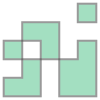

In [6]:
sedona.sql(
    """
    WITH pixelized AS (
        SELECT 
            RS_PixelAsPolygons(rast, 1) AS pixels
        FROM raster
    )
    SELECT
        ST_Union_Aggr(pixel.geom) AS geom
    FROM pixelized
    LATERAL VIEW explode(pixels) AS pixel
    WHERE pixel.value > 2 and pixel.value < 14
    """
).collect()[0][0]

## Geometry functions

## RS_Envelope

In [7]:
sedona.sql(
    """
    SELECT 
        RS_Envelope(rast) as geom
    FROM raster
    """
).show(1, False)

+-----------------------------------+
|geom                               |
+-----------------------------------+
|POLYGON ((0 0, 0 5, 5 5, 5 0, 0 0))|
+-----------------------------------+



## RS_ConvexHull

In [8]:
sedona.sql(
    """
    SELECT 
        RS_ConvexHull(rast) as geom
    FROM raster
    """
).show(1, False)

+-----------------------------------+
|geom                               |
+-----------------------------------+
|POLYGON ((0 5, 5 5, 5 0, 0 0, 0 5))|
+-----------------------------------+



In [9]:
sedona.sql(
    """
    SELECT 
        RS_ConvexHull(skew_raster) as convex_hull_geom,
        RS_Envelope(skew_raster) as envelope_geom
    FROM raster
    """
).show(1, False)

+------------------------------------+-------------------------------------+
|convex_hull_geom                    |envelope_geom                        |
+------------------------------------+-------------------------------------+
|POLYGON ((0 5, 5 5, 10 0, 5 0, 0 5))|POLYGON ((0 0, 0 5, 10 5, 10 0, 0 0))|
+------------------------------------+-------------------------------------+



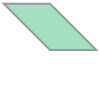

In [10]:
sedona.sql(
    """
    SELECT 
        RS_ConvexHull(skew_raster) as convex_hull_geom,
        RS_Envelope(skew_raster) as envelope_geom
    FROM raster
    """
).select("convex_hull_geom").collect()[0][0]

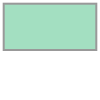

In [11]:
sedona.sql(
    """
    SELECT 
        RS_ConvexHull(skew_raster) as convex_hull_geom,
        RS_Envelope(skew_raster) as envelope_geom
    FROM raster
    """
).select("envelope_geom").collect()[0][0]

# Raster accessors

In [12]:
sedona.sql(
    """
    SELECT 
        RS_Height(rast) as height,
        RS_Rotation(rast) as rotation,
        RS_ScaleX(rast) as scale_x,
        RS_SkewX(rast) as skew_x
    FROM raster
    """
).show()

+------+--------+-------+------+
|height|rotation|scale_x|skew_x|
+------+--------+-------+------+
|     5|     0.0|    1.0|   0.0|
+------+--------+-------+------+



# Raster band accessors

## RS_Count

In [13]:
sedona.sql(
    """
    SELECT 
        RS_Count(rast) as count
    FROM raster
    """
).show()

+-----+
|count|
+-----+
|   25|
+-----+



## RS_SummaryStatsAll

In [14]:
sedona.sql(
    """
    SELECT r.stats.*
    FROM (
      SELECT
          RS_SummaryStatsAll(rast, 1) AS stats
      FROM raster
    ) AS r
    """
).show()

+-----+-----+----+-----------------+---+----+
|count|  sum|mean|           stddev|min| max|
+-----+-----+----+-----------------+---+----+
| 25.0|242.0|9.68|5.842739083683268|1.0|20.0|
+-----+-----+----+-----------------+---+----+



## Raster-based operators

In [15]:
## RS_AddBand

In [16]:
sedona.sql(
    """
      SELECT
          RS_NUmBands(
              RS_AddBand(rast, skew_raster)
          ) AS num_bands
      FROM raster
    """
).show()

+---------+
|num_bands|
+---------+
|        2|
+---------+



In [17]:
## RS_Clip

In [18]:
sedona.sql(
    """
    SELECT
        RS_Envelope(RS_Clip(
            rast,
            1,
            ST_GeomFromText('POLYGON((1 1, 1 2, 2 2, 2 1, 1 1))')
        )) AS envelope
    FROM raster
    """
).show(10, False)

+-----------------------------------+
|envelope                           |
+-----------------------------------+
|POLYGON ((1 1, 1 2, 2 2, 2 1, 1 1))|
+-----------------------------------+



In [19]:
## RS_Interpolate

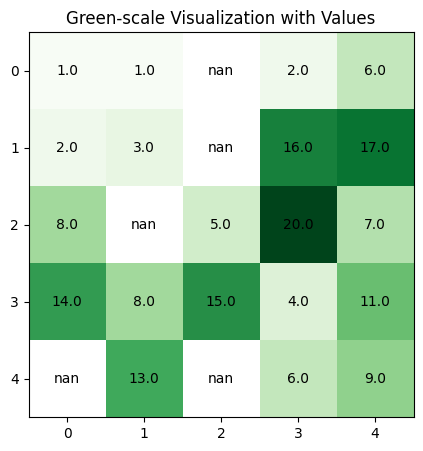

In [20]:
plot_sedona_raster(sedona.sql("select rast2 AS rast from raster"), 0)

In [21]:
interpolation = sedona.sql(
    """
    SELECT 
        RS_Interpolate(rast2, 2, 'Fixed', 1.5) AS rast
    FROM raster
    """
)

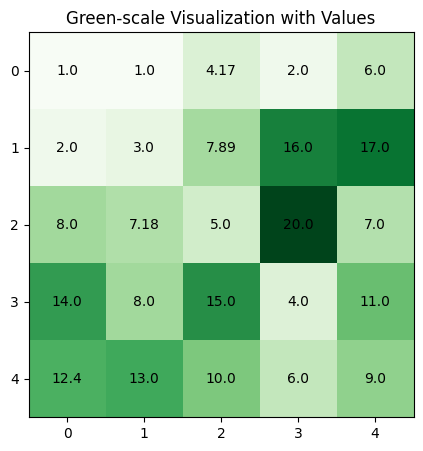

In [22]:
plot_sedona_raster(interpolation, 0)

# Raster Tiles

In [23]:
sedona.sql(
    """
    SELECT rast.*
    FROM raster
    LATERAL VIEW RS_TileExplode(rast, 2, 2) rast
    """
).show()

+---+---+--------------------+
|  x|  y|                tile|
+---+---+--------------------+
|  0|  0|GridCoverage2D["g...|
|  1|  0|GridCoverage2D["g...|
|  2|  0|GridCoverage2D["g...|
|  0|  1|GridCoverage2D["g...|
|  1|  1|GridCoverage2D["g...|
|  2|  1|GridCoverage2D["g...|
|  0|  2|GridCoverage2D["g...|
|  1|  2|GridCoverage2D["g...|
|  2|  2|GridCoverage2D["g...|
+---+---+--------------------+



# Vizualize 

In [24]:
from sedona.raster_utils.SedonaUtils import SedonaUtils

htmlDF = sedona.sql(
    """
    SELECT 
        RS_AsImage(skew_raster, 300)
    FROM raster
    """
)

SedonaUtils.display_image(htmlDF)

/tmp/ipykernel_317/3688504622.py:1: DeprecationWarning: Importing from 'sedona.raster_utils.SedonaUtils' is deprecated. Please use 'sedona.spark.raster_utils.SedonaUtils' instead.
  from sedona.raster_utils.SedonaUtils import SedonaUtils


,"rs_asimage(skew_raster, 300)"
0,


In [25]:
from sedona.raster_utils.SedonaUtils import SedonaUtils

htmlDF = sedona.sql(
    """
    SELECT 
        RS_AsImage(rast, 300)
    FROM raster
    """
)

SedonaUtils.display_image(htmlDF)

,"rs_asimage(rast, 300)"
0,


## RS_AsMatrix

In [26]:
print(
    sedona.sql(
    """
    SELECT
        RS_AsMatrix(rast) 
    FROM raster
    """
).head()[0])

| 1.0   1.0  16.0   2.0   6.0|
| 2.0   3.0  12.0  16.0  17.0|
| 8.0  17.0   5.0  20.0   7.0|
|14.0   8.0  15.0   4.0  11.0|
|10.0  13.0  19.0   6.0   9.0|



# Raster Consturctors

## RS_MakeRaster and RS_MakeEmptyRaster

In [27]:
input_raster = [
    [1, 1, 16, 2, 6],
    [2, 3, 12, 16, 17],
    [8, 17, 5, 20, 7],
    [14, 8, 15, 4, 11],
    [10, 13, 19, 6, 9]
]

flatten = list(itertools.chain.from_iterable(input_raster))

array_input = ", ".join([str(number) for number in flatten ])

raster_df = sedona.sql(
    f"""
    WITH empty_raster AS (
        SELECT RS_MakeEmptyRaster(1, 5, 5, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 4326) AS rast
    )
    SELECT 
        RS_MakeRaster(rast, 'D', ARRAY({array_input})) AS rast
    FROM empty_raster
    """
)


In [28]:
print(
    raster_df.selectExpr("RS_AsMatrix(rast)").head()[0]
)

| 1.0   1.0  16.0   2.0   6.0|
| 2.0   3.0  12.0  16.0  17.0|
| 8.0  17.0   5.0  20.0   7.0|
|14.0   8.0  15.0   4.0  11.0|
|10.0  13.0  19.0   6.0   9.0|



In [29]:
raster_df.selectExpr("Rs_Envelope(rast)").head()

Row(rs_envelope(rast)=<POLYGON ((0 0, 0 5, 5 5, 5 0, 0 0))>)

# Write to raster

## RS_AsArcGrid

In [30]:
sedona.sql(
    """
    SELECT 
        RS_AsArcGrid(rast) 
    FROM raster
    """
).show()

+--------------------+
|  rs_asarcgrid(rast)|
+--------------------+
|[4E 43 4F 4C 53 2...|
+--------------------+



# RS_AsGeoTiff

In [31]:
sedona.sql(
    """
    SELECT 
        RS_AsGeoTiff(rast) 
    FROM raster
    """
).show()

+--------------------+
|  rs_asgeotiff(rast)|
+--------------------+
|[4D 4D 00 2A 00 0...|
+--------------------+



## RS_AsPNG

In [32]:
sedona.sql(
    """
    SELECT 
        RS_AsPNG(rast) 
    FROM raster
    """
).show()

+--------------------+
|      rs_aspng(rast)|
+--------------------+
|[89 50 4E 47 0D 0...|
+--------------------+



## Saving to the file

In [33]:
geotiff_binary = sedona.sql(
    """
    SELECT 
        RS_AsGeoTiff(r.tile) 
    FROM raster
    LATERAL VIEW RS_TileExplode(rast, 2, 2) r
    """
)

In [34]:
import uuid
import os

def save_to_file(data: [bytes], path: str):
    file_name = str(uuid.uuid4())
    with open(os.path.join(path, f"{file_name}.tif"), "wb") as f:
        f.write(data)

In [35]:
import os
os.makedirs("data/sql_functions/writing")
geotiff_binary.foreach(lambda x: save_to_file(x[0], "data/sql_functions/writing"))